# Hypothesis Visualization — KLW Perceptual Choice Model

## Task & setting

Participants choose between a **safe option** (certain payoff $c$, probability $p=1$) and a **risky option** (payoff $x$, probability $p=0.55$). Payoffs range ~5–90 CHF, presented as Arabic digits. The key question is how **developmental dyscalculia (DD)** affects the internal representation of numerical magnitudes and how this propagates to risky choice behaviour.

---

## The KLW / Bayesian perceptual model

All computations happen in **log-space** ($s = \log(\text{payoff})$). This implements Weber's law: equal relative noise across magnitudes.

### 1 · Noisy internal representations

Each payoff produces a noisy log-magnitude observation:

$$r_c \sim \mathcal{N}(s_c,\; \sigma_c^2), \qquad r_x \sim \mathcal{N}(s_x,\; \sigma_x^2)$$

In the **baseline KLW model** both options share the same noise: $\sigma_c = \sigma_x = \sigma$.

### 2 · Bayesian updating with a range prior

The observer has a prior over the full payoff range:

$$p(s) = \mathcal{N}(\mu_p,\; \sigma_p^2), \qquad \mu_p = \mathbb{E}[\log c_i],\quad \sigma_p = \text{std}[\log c_i]$$

The posterior for each option is a precision-weighted average (shrinkage toward the prior):

$$\mu_\text{post} = \frac{r\,\sigma_p^2 + \mu_p\,\sigma^2}{\sigma^2 + \sigma_p^2}, \qquad \sigma_\text{post}^2 = \frac{\sigma^2\,\sigma_p^2}{\sigma^2 + \sigma_p^2}$$

### 3 · Choice probability

The decision signal is the difference of posterior means:

$$\delta = \mathbb{E}[s_x \mid r_x] - \mathbb{E}[s_c \mid r_c]$$

$$P(\text{choose risky}) = \Phi\!\left(\frac{\delta}{\varsigma}\right), \qquad \varsigma^2 = \sigma_{\text{post},x}^2 + \sigma_{\text{post},c}^2$$

### 4 · Link to the probit model

The psychometric curve is fit as $P(\text{risky}) = \Phi\bigl(\gamma\,(\log(x/c) - \text{RNP})\bigr)$.  
From the KLW model: $\gamma = (1-w)/\varsigma$ where $w = \sigma^2/(\sigma^2+\sigma_p^2)$ is the shrinkage weight.  
Larger $\sigma$ → more shrinkage → smaller $\delta$ → shallower slope $\gamma$.

---

## Three hypotheses

Starting model: **KLW** = Symmetric noise for both evidences ($\sigma_c = \sigma_x$)
→ Probit curves for small/large stakes **overlap** (no stake-size effect on RNP); slope reflects baseline noise



| Panel | Model | Prediction |
|-------|-------|------------|
| **H1a**  | classic KLW with more general noise | more noise → more risk aversion according to KLW **overlap** |
| **H1b**  | Asymmetric noise ($\sigma_x < \sigma_c$) | one option is pulled more to the prior - over/underestimation pattern becomes the opposite for smaller versus large stakes |
| **H2**  | Geometry of representational space: more linear/natural than log (n $\uparrow$ → $\sigma\downarrow$) | Steeper slopes for larger stakes |

**H2 key mechanism:** with $\sigma_x > \sigma_c$ the shrinkage offset on $\delta$ is $(w_c - w_x)(s_c - \mu_p)$, which changes sign as $s_c$ crosses $\mu_p$ — i.e. exactly between small and large stakes.

### Understand indifference point/RNP in terms of probit model & relation to cumulative density function parameters
x = indifference point (where prop. chose risky = 1/2)
$$ 
\frac{1}{2} = \frac{1}{1+e^{\beta_0 - \beta_1*x}} = = \frac{1}{1+e^{\frac{x-\mu}{\sigma}}} 
$$

$$
  1 = e^{\beta_0 - \beta_1*x} \\
  0 = \beta_0 - \beta_1*x \\
  \beta_0  =\beta_1 *x \\
  x = - \frac{\beta_0}{\beta_1} = indifference Point = log(\frac{1}{RNP}) 
$$

$$   RNP = \pi = e^{-\frac{\beta_0}{\beta_0}} $$


So the parameters of the probit model `chose_risky ~ intercept + gamma * x` are a reparameterization of the cumulative density function (\mu, \sigma)... ?

$$ 
    \beta_0 + \beta_1 * x = \frac{x-\mu}{\sigma} \\
    \beta_1 = \frac{1}{\sigma}  \\
    \beta_0 = -\frac{\mu}{\sigma} \\
    \mu = indPoint = -{\beta_0 } * {\sigma} 
    
$$

what we fit it $\beta_0$ + $\beta_1$, but $\mu$ is the real intercept that represents the RNP (or better said, $\frac{1}{RNP}$)

In [1]:
import numpy as np
import scipy.stats as ss
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import os.path as op

bids_folder    = '/Users/mrenke/data/ds-dnumrisk'
out_folder     = op.join(bids_folder, 'plots_and_ims', 'paper_riskDD')
figures_folder = op.join(out_folder, 'figures')

sns.set_theme('paper', 'white', font='helvetica', font_scale=1.2)

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


The KLW / Bayesian perceptual choice model
Everything is in log-space. Let s_c = log(c) and s_x = log(x) be the true log-payoffs of the safe and risky options.

Internal representations are noisy Gaussians:

r_c ~ N(s_c, σ²)
r_x ~ N(s_x, σ²)

Bayesian updating with a prior over the full payoff range. 
The prior is 
N(μ_p, σ_p²) — set μ_p = mean(log(all payoffs)), 
σ_p = std(log(all payoffs)). 

The posterior for each option is:
μ_post = (r · σ_p² + μ_p · σ²) / (σ² + σ_p²)
σ_post² = (σ² · σ_p²) / (σ² + σ_p²)

Choice probability (risky chosen) is determined by whether the posterior mean difference δ = E[s_x|r_x] - E[s_c|r_c] exceeds zero
P(choose risky) = Φ(δ / ς)
where ς² = σ_post_x² + σ_post_c²
         = 2 · (σ² · σ_p²) / (σ² + σ_p²)    [symmetric case]

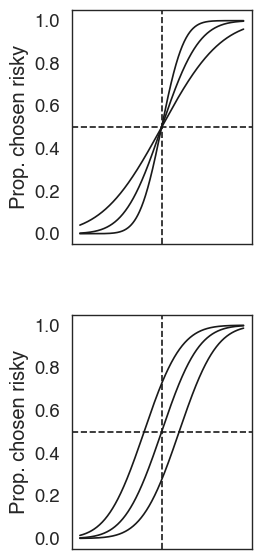

In [2]:
import scipy.stats as ss

sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')

x = np.linspace(-.8, 2, 500)
mu_rn = np.log(1/0.55)
fig, axs = plt.subplots(2, 1, figsize=(3, 7))

for sd in [.3, .5, .8]:
    d = ss.norm(mu_rn, sd)
    axs[0].plot(x, d.cdf(x), color='k')

for mu in [ mu_rn - 0.3, mu_rn, mu_rn + 0.3]:
    d = ss.norm(mu, .5)
    axs[1].plot(x, d.cdf(x), color='k')

for ax in axs:
    ax.axvline(mu_rn, color='k', linestyle='--')
    ax.axhline(0.5, color='k', linestyle='--')
    ax.set(xticks=[], ylabel='Prop. chosen risky')

fig.subplots_adjust(hspace = 0.3, left=0.3) # adjust vertical space between axes

In [3]:
P_RISKY = 0.55    # probability of the risky outcome

small_stake_color =  "#6B91C3" 
large_stake_color =  "#12396B" 

# ── Core computation ─────────────────────────────────────────────────────────
def get_posterior(mu_obs, sd_obs, mu_prior, sd_prior):
    """Precision-weighted Gaussian posterior: combines likelihood N(mu_obs, sd_obs²)
    with prior N(mu_prior, sd_prior²)."""
    var_obs, var_prior = sd_obs**2, sd_prior**2
    mu_post = (mu_obs * var_prior + mu_prior * var_obs) / (var_obs + var_prior)
    sd_post = np.sqrt((var_obs * var_prior) / (var_obs + var_prior))
    return mu_post, sd_post

def plot_probit_curves(ax, s_c_small, s_c_large, sigma_c, sigma_x, mu_p, sigma_p):
    """
    Psychometric (probit) curves: P(choose risky) vs log(x/c).

    The decision signal is:
        delta = mu_post_x - mu_post_c + log(p_risky)
    The log(p_risky) term shifts the RNP rightward (risk-neutral point > 0),
    because the risky option must compensate for p < 1.

    Symmetric noise (KLW / H1):
        delta = (1-w)*log_ratio + log(p)
        RNP   = -log(p) / (1-w)  =  log(1/0.55) / (1-w)
        → RNP shifts RIGHT as sigma increases (larger w → smaller 1-w)
        → slope (gamma) decreases with sigma
        → small/large stake curves still OVERLAP (no stake-size interaction)

    Asymmetric noise (H2, sigma_x > sigma_c):
        delta gains an extra term (w_c - w_x)*(s_c - mu_p) that flips sign
        across mu_p  →  curves SEPARATE for small vs large stakes
    """
    log_ratios = np.linspace(-1, 2.5, 300)
    log_p      = np.log(P_RISKY)          # ≈ -0.598

    # Posterior SDs depend only on sigma (not the mean)
    _, sd_pc = get_posterior(0, sigma_c, mu_p, sigma_p)
    _, sd_px = get_posterior(0, sigma_x, mu_p, sigma_p)
    sigma_delta = np.sqrt(sd_pc**2 + sd_px**2)

    # Shrinkage weights
    w_c = sigma_c**2 / (sigma_c**2 + sigma_p**2)
    w_x = sigma_x**2 / (sigma_x**2 + sigma_p**2)

    for s_c, ls, lbl, color in [(s_c_small, '-',  'Small stakes',  "#6B91C3" ),
                          (s_c_large, '--', 'Large stakes',  "#12396B" )]:
        mu_pc   = (1 - w_c) * s_c + w_c * mu_p
        delta_0 = (1 - w_x) * s_c + w_x * mu_p - mu_pc   # stake-size offset
        delta   = (1 - w_x) * log_ratios + delta_0 + log_p  # include p=0.55
        p_risky = ss.norm.cdf(delta / sigma_delta)

        ax.plot(log_ratios, p_risky, color=color, ls=ls, lw=3.0, label=lbl)

    ax.axhline(0.5, color='gray', ls=':', lw=0.8, alpha=0.7)
    ax.axvline(0.0, color='gray', ls=':', lw=0.8, alpha=0.7)
    ax.set_xlabel('log(risky / safe)', fontsize=9)
    ax.set_ylabel('P(choose risky)', fontsize=9)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlim(-1, 2.5)
    ax.set_yticks([0, 0.5, 1])
    #ax.set_xticks([-1, 0, 1])
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8, loc='upper left')
    sns.despine(ax=ax)

In [4]:
from utils_riskBehav import plot_risky_bayerian_inference
palette = sns.color_palette('Set2', 4)#[::-1]

def get_posterior(mu1, sd1, mu2, sd2):
    var1, var2 = sd1**2, sd2**2
    return mu1 + (var1/(var1+var2))*(mu2 - mu1), np.sqrt((var1*var2)/(var1+var2))


## KLW - symmetric noise

absolute noise increase --> predicts ∂IndPoint

(<Figure size 450x350 with 1 Axes>, <Axes: >)

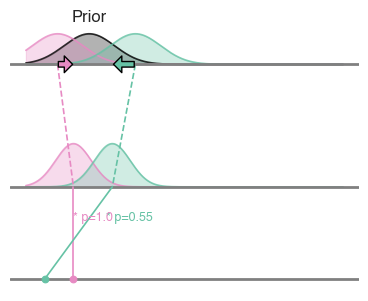

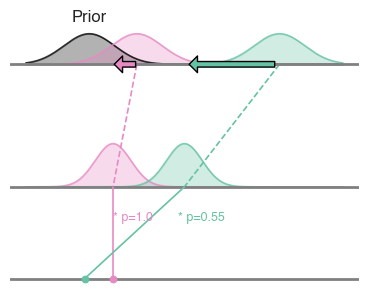

In [5]:
## classic KLW model : same evidence_sd & same prior
x = np.linspace(2, 12, 1000)

sd_n1 = 0.8
sd_n2 = sd_n1
mu_prior, std_prior = 4., .8
RNP = 0.55

# small stakes
mu_n1  = 3 #     # safe
mu_n2 = (mu_n1/RNP) # risky
mu_post_n1, sd_post_n1 = get_posterior(mu_n1, sd_n1, mu_prior, std_prior)
mu_post_n2, sd_post_n2 = get_posterior(mu_n2, sd_n2, mu_prior, std_prior)
plot_risky_bayerian_inference(mu_prior, std_prior,
                                    mu_n1, sd_n1, # safe
                                    mu_n2, sd_n2, # risky
                                    mu_post_n1, sd_post_n1, 
                                    mu_post_n2, sd_post_n2,
                                    x, palette)

#large stakes
mu_n1 = 5.5
mu_n2 = (mu_n1/RNP)
mu_post_n1, sd_post_n1 = get_posterior(mu_n1, sd_n1, mu_prior, std_prior)
mu_post_n2, sd_post_n2 = get_posterior(mu_n2, sd_n2, mu_prior, std_prior)
plot_risky_bayerian_inference(mu_prior, std_prior,
                                    mu_n1, sd_n1, # safe
                                    mu_n2, sd_n2, # risky
                                    mu_post_n1, sd_post_n1, 
                                    mu_post_n2, sd_post_n2,
                                    x, palette)

#plt.savefig(op.join(plot_folder_paper, 'risky_bayesian_inference_smallStakes.pdf'), bbox_inches='tight')
#plt.savefig(op.join(plot_folder_paper, 'risky_bayesian_inference_smallStakes.pdf'), bbox_inches='tight')

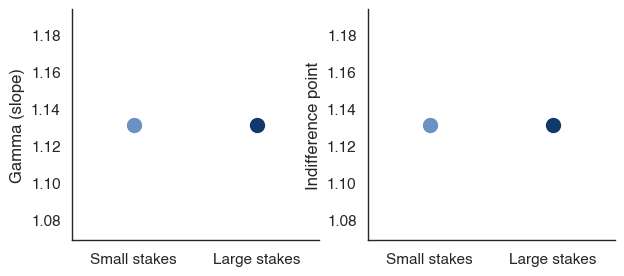

In [6]:
# plot gamma and indifference point for small and large stakes
markersize = 10 
# small stakes
sd_delta = np.sqrt(sd_n1**2 + sd_n2**2) # = overall slope of probit

fig, axs = plt.subplots(1,2, figsize=(7, 3))
#gammas
axs[0].plot(0,sd_delta, 'o', color=small_stake_color, markersize=markersize )
axs[0].plot(1,sd_delta, 'o', color=large_stake_color, markersize=markersize)
axs[0].set(xticks=[0,1], xlim=(-0.5, 1.5),
           xticklabels=['Small stakes', 'Large stakes'], 
           ylabel='Gamma (slope)')

axs[1].plot(0,sd_delta, 'o', color=small_stake_color, markersize=markersize)
axs[1].plot(1,sd_delta, 'o', color=large_stake_color, markersize=markersize )
axs[1].set(xticks=[0,1], xlim=(-0.5, 1.5),
           xticklabels=['Small stakes', 'Large stakes'], 
           ylabel='Indifference point')
sns.despine()

Text(0.5, 0.98, 'sigma_x = sigma_c')

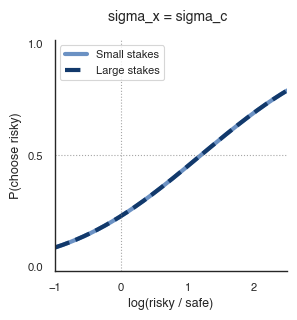

In [7]:
fig, ax = plt.subplots(figsize=(3, 3))
plot_probit_curves(ax, 
                   s_c_small=3, 
                   s_c_large=5.5, 
                   sigma_c=sd_n1, 
                   sigma_x=sd_n2, 
                   mu_p=mu_prior, 
                   sigma_p = std_prior)
fig.suptitle('sigma_x = sigma_c', fontsize=10)

Text(0.5, 0.98, 'sigma_x = sigma_c but general more noisy')

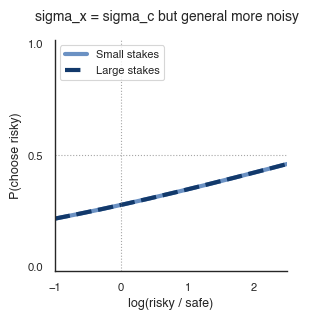

In [8]:
fig, ax = plt.subplots(figsize=(3, 3))
plot_probit_curves(ax, 
                   s_c_small=3, 
                   s_c_large=5.5, 
                   sigma_c=sd_n1*2, 
                   sigma_x=sd_n2*2 , 
                   mu_p=mu_prior, 
                   sigma_p = std_prior)
fig.suptitle('sigma_x = sigma_c but general more noisy', fontsize=10)

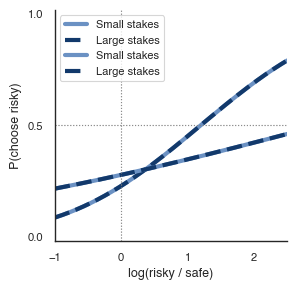

In [9]:
fig, ax = plt.subplots(figsize=(3, 3))
plot_probit_curves(ax, 
                   s_c_small=3, 
                   s_c_large=5.5, 
                   sigma_c=sd_n1, 
                   sigma_x=sd_n2, 
                   mu_p=mu_prior, 
                   sigma_p = std_prior)
plot_probit_curves(ax, 
                   s_c_small=3, 
                   s_c_large=5.5, 
                   sigma_c=sd_n1*2, 
                   sigma_x=sd_n2*2 , 
                   mu_p=mu_prior, 
                   sigma_p = std_prior)


## Asymmetric noise OR ∂geometry (noise different across representational space / less log compression)

(<Figure size 450x350 with 1 Axes>, <Axes: >)

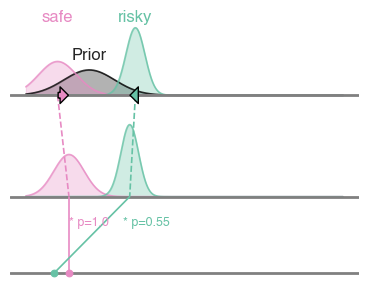

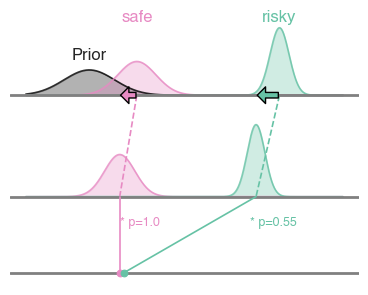

In [10]:
x = np.linspace(2, 12, 1000)

sd_n1 = 0.6 # safe
sd_n2 = sd_n1 * 0.5 # risky
mu_prior, std_prior = 4., .8
RNP = 0.55
# small stakes
mu_n1  = 3 #     # safe
mu_n2 = (mu_n1/RNP) # risky
mu_post_n1, sd_post_n1 = get_posterior(mu_n1, sd_n1, mu_prior, std_prior)
mu_post_n2, sd_post_n2 = get_posterior(mu_n2, sd_n2, mu_prior, std_prior)
plot_risky_bayerian_inference(mu_prior, std_prior,
                                    mu_n1, sd_n1, # safe
                                    mu_n2, sd_n2, # risky
                                    mu_post_n1, sd_post_n1, 
                                    mu_post_n2, sd_post_n2,
                                    x, palette)

#large stakes
mu_n1 = 5.5
mu_n2 = (mu_n1/RNP)
mu_post_n1, sd_post_n1 = get_posterior(mu_n1, sd_n1, mu_prior, std_prior)
mu_post_n2, sd_post_n2 = get_posterior(mu_n2, sd_n2, mu_prior, std_prior)
plot_risky_bayerian_inference(mu_prior, std_prior,
                                    mu_n1, sd_n1, # safe
                                    mu_n2, sd_n2, # risky
                                    mu_post_n1, sd_post_n1, 
                                    mu_post_n2, sd_post_n2,
                                    x, palette)

#plt.savefig(op.join(plot_folder_paper, 'risky_bayesian_inference_smallStakes.pdf'), bbox_inches='tight')
#plt.savefig(op.join(plot_folder_paper, 'risky_bayesian_inference_smallStakes.pdf'), bbox_inches='tight')

Text(0.5, 0.98, 'noise_risky < noise_safe')

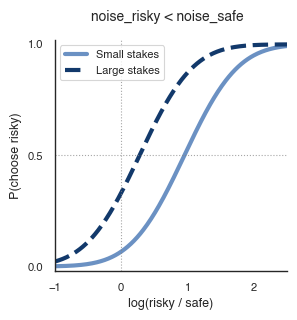

In [11]:
fig, ax = plt.subplots(figsize=(3, 3))
plot_probit_curves(ax, 
                   s_c_small=3, 
                   s_c_large=5.5, 
                   sigma_c=sd_n1, 
                   sigma_x=sd_n2, 
                   mu_p=mu_prior, 
                   sigma_p = std_prior)
fig.suptitle('noise_risky < noise_safe', fontsize=10)

In [12]:
# Indifference points shift is the same for asymmetric and geometric account 
indPoint_small = 0.6
indPoint_large = 0.3


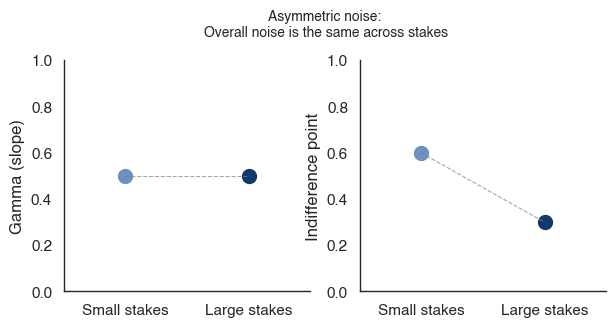

In [13]:
# for asymmetric noise - overall noise stays the same but indPoint shifts! 
gamma_small = 0.5
gamma_large = 0.5

markersize = 10 
fig, axs = plt.subplots(1,2, figsize=(7, 3))
fig.suptitle('Asymmetric noise: \n' \
            'Overall noise is the same across stakes', 
            fontsize=10, y =1.05)
#gammas
axs[0].plot(0,gamma_small, 'o', color=small_stake_color, markersize=markersize )
axs[0].plot(1,gamma_large, 'o', color=large_stake_color, markersize=markersize)
# connecting lines
axs[0].plot([0,1], [gamma_small, gamma_large], color='gray', ls='--', lw=0.8, alpha=0.7)
axs[0].set(xticks=[0,1], xlim=(-0.5, 1.5),
           xticklabels=['Small stakes', 'Large stakes'], 
           ylabel='Gamma (slope)', ylim=(0,1),)

axs[1].plot(0,indPoint_small, 'o', color=small_stake_color, markersize=markersize)
axs[1].plot(1,indPoint_large, 'o', color=large_stake_color, markersize=markersize )
# connecting lines
axs[1].plot([0,1], [indPoint_small, indPoint_large], color='gray', ls='--', lw=0.8, alpha=0.7)
axs[1].set(xticks=[0,1], xlim=(-0.5, 1.5),
           xticklabels=['Small stakes', 'Large stakes'], 
           ylabel='Indifference point', ylim=(0,1), )
sns.despine()

# Geometric account

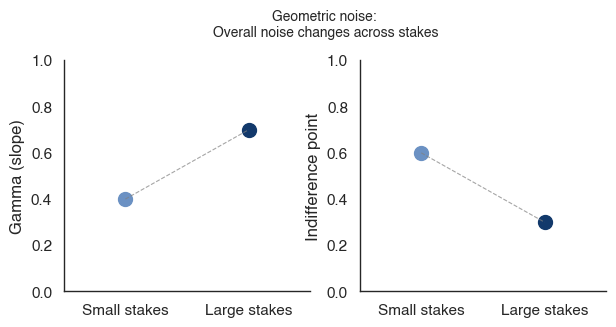

In [116]:
# for geometry overall noise changes across stakes
gamma_small = 0.4
gamma_large = 0.7

markersize = 10 
fig, axs = plt.subplots(1,2, figsize=(7, 3))
fig.suptitle('Geometric noise: \n' \
            'Overall noise changes across stakes', 
            fontsize=10, y =1.05)
#gammas
axs[0].plot(0,gamma_small, 'o', color=small_stake_color, markersize=markersize )
axs[0].plot(1,gamma_large, 'o', color=large_stake_color, markersize=markersize)
# connecting lines
axs[0].plot([0,1], [gamma_small, gamma_large], color='gray', ls='--', lw=0.8, alpha=0.7)
axs[0].set(xticks=[0,1], xlim=(-0.5, 1.5),
           xticklabels=['Small stakes', 'Large stakes'], 
           ylabel='Gamma (slope)', ylim=(0,1),)

axs[1].plot(0,indPoint_small, 'o', color=small_stake_color, markersize=markersize)
axs[1].plot(1,indPoint_large, 'o', color=large_stake_color, markersize=markersize )
# connecting lines
axs[1].plot([0,1], [indPoint_small, indPoint_large], color='gray', ls='--', lw=0.8, alpha=0.7)
axs[1].set(xticks=[0,1], xlim=(-0.5, 1.5),
           xticklabels=['Small stakes', 'Large stakes'], 
           ylabel='Indifference point', ylim=(0,1), )
sns.despine()

(<Figure size 450x350 with 1 Axes>, <Axes: >)

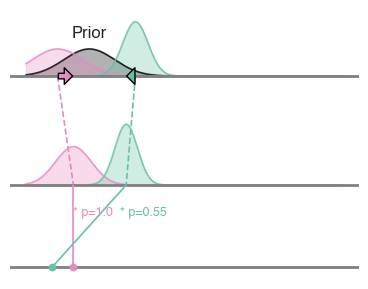

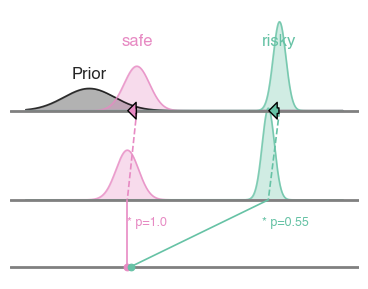

In [119]:
x = np.linspace(2, 12, 1000)


mu_prior, std_prior = 4., .8
RNP = 0.55
# small stakes
sd_n1 = 0.8 # safe
sd_n2 = sd_n1 * 0.5 # risky
mu_n1  = 3 #     # safe
mu_n2 = (mu_n1/RNP) # risky
mu_post_n1, sd_post_n1 = get_posterior(mu_n1, sd_n1, mu_prior, std_prior)
mu_post_n2, sd_post_n2 = get_posterior(mu_n2, sd_n2, mu_prior, std_prior)
plot_risky_bayerian_inference(mu_prior, std_prior,
                                    mu_n1, sd_n1, # safe
                                    mu_n2, sd_n2, # risky
                                    mu_post_n1, sd_post_n1, 
                                    mu_post_n2, sd_post_n2,
                                    x, palette)

#large stakes --> noise becomes smaller! 
sd_n1 = 0.4 # safe
sd_n2 = sd_n1 * 0.5 # risky
mu_n1 = 5.5
mu_n2 = (mu_n1/RNP)
mu_post_n1, sd_post_n1 = get_posterior(mu_n1, sd_n1, mu_prior, std_prior)
mu_post_n2, sd_post_n2 = get_posterior(mu_n2, sd_n2, mu_prior, std_prior)
plot_risky_bayerian_inference(mu_prior, std_prior,
                                    mu_n1, sd_n1, # safe
                                    mu_n2, sd_n2, # risky
                                    mu_post_n1, sd_post_n1, 
                                    mu_post_n2, sd_post_n2,
                                    x, palette)

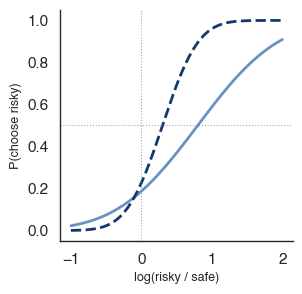

In [133]:
log_ratios = np.linspace(-1, 2, 300)
c_curve_smallS = ss.norm.cdf(log_ratios, loc=0.8, scale=0.9)
c_curve_largeS = ss.norm.cdf(log_ratios, loc=0.3, scale=0.4)

fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(log_ratios, c_curve_smallS, color=small_stake_color, ls='-', lw=2.0, label='Small Stake')
ax.plot(log_ratios, c_curve_largeS, color=large_stake_color, ls='--', lw=2.0, label='Large Stake' )
sns.despine()
ax.set_xlabel('log(risky / safe)', fontsize=9)
ax.set_ylabel('P(choose risky)', fontsize=9)
ax.axhline(0.5, color='gray', ls=':', lw=0.8, alpha=0.7)
ax.axvline(0.0, color='gray', ls=':', lw=0.8, alpha=0.7)

## Asymetry other way around - safe option more precise

(<Figure size 450x350 with 1 Axes>, <Axes: >)

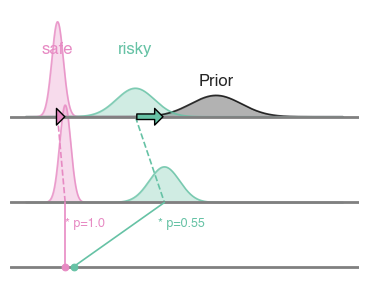

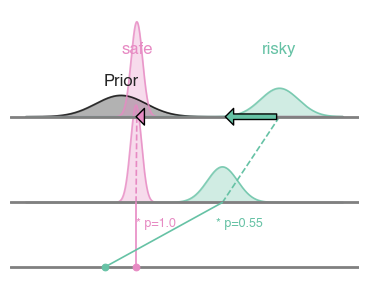

In [86]:
# save option more precise now... 
# -- but had to tinker with the prior to get the curves to look good (but that is not the point of this figure, just to show the effect of asymmetric noise)

sd_n2 = 0.6 # risky
sd_n1 = sd_n2 * 0.3 # safe

std_prior =  .8
RNP = 0.55

# small stakes
mu_prior = 8
mu_n1  = 3 #     # safe
mu_n2 = (mu_n1/RNP) # risky
mu_post_n1, sd_post_n1 = get_posterior(mu_n1, sd_n1, mu_prior, std_prior)
mu_post_n2, sd_post_n2 = get_posterior(mu_n2, sd_n2, mu_prior, std_prior)
plot_risky_bayerian_inference(mu_prior, std_prior,
                                    mu_n1, sd_n1, # safe
                                    mu_n2, sd_n2, # risky
                                    mu_post_n1, sd_post_n1, 
                                    mu_post_n2, sd_post_n2,
                                    x, palette)

#large stakes
mu_prior = 5
mu_n1 = 5.5
mu_n2 = (mu_n1/RNP)
mu_post_n1, sd_post_n1 = get_posterior(mu_n1, sd_n1, mu_prior, std_prior)
mu_post_n2, sd_post_n2 = get_posterior(mu_n2, sd_n2, mu_prior, std_prior)
plot_risky_bayerian_inference(mu_prior, std_prior,
                                    mu_n1, sd_n1, # safe
                                    mu_n2, sd_n2, # risky
                                    mu_post_n1, sd_post_n1, 
                                    mu_post_n2, sd_post_n2,
                                    x, palette)

#plt.savefig(op.join(plot_folder_paper, 'risky_bayesian_inference_smallStakes.pdf'), bbox_inches='tight')
#plt.savefig(op.join(plot_folder_paper, 'risky_bayesian_inference_smallStakes.pdf'), bbox_inches='tight')

Text(0.5, 0.98, 'noise_risky > noise_safe')

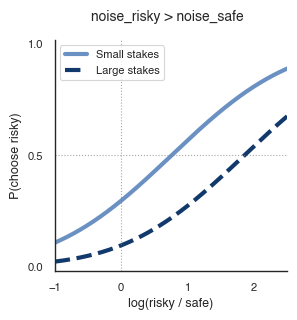

In [77]:

fig, ax = plt.subplots(figsize=(3, 3))
plot_probit_curves(ax, 
                   s_c_small=3, 
                   s_c_large=5.5, 
                   sigma_c=0.5, 
                   sigma_x=0.8, 
                   mu_p=mu_prior, 
                   sigma_p = std_prior)
fig.suptitle('noise_risky > noise_safe', fontsize=10)

## how would ∂geometry & ∂noise-symmetry affect choice curves differently?